# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 5: Projeto via Resposta em Frequência

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professores:** Fernando J. Von Zuben / Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** K, L, U ou V <br>
**Aluno(a): Mariana Leister Gonçalves** , **RA:** 233115 <br>
**Aluno(a): Mariana Vasconcelos Silva**, **RA:** 251295 <br>
**Aluno(a): Marina Alves Farias** , **RA:** 188521 <br>

## Bibliotecas

In [6]:
try:
    import control as ct
except ImportError:
    !pip install control
    import control as ct

In [1]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from tqdm import tqdm
import csv

import sympy

# # Google Drive Mount (Colab)
# from google.colab import drive
# drive.mount('/content/drive')

## Funções

In [2]:
def plot_resposta_sistema(df, Gw, Gu, C, titulo):
    """
    Plota a resposta ao distúrbio de um sistema com e sem compensação.

    Parâmetros:
    -----------
    df : DataFrame
        Deve conter as colunas 't' (tempo) e 'w' (entrada/distúrbio)
    Gw : control.TransferFunction
        Função de transferência do sistema sem compensação
    Gu : control.TransferFunction
        Função de transferência do caminho de controle
    C : control.TransferFunction
        Controlador
    """

    # Sistema compensado
    Tw = Gw / (1 + Gu * C)

    # Simulações
    t_nc, y_nc = ct.forced_response(Gw, T=df["t"].values, U=df["w"].values)
    t_c, y_c = ct.forced_response(Tw, T=df["t"].values, U=df["w"].values)

    # Plot
    fig = go.Figure()

    fig.add_trace(go.Scatter(
        x=t_nc,
        y=y_nc,
        mode='lines',
        name='Não compensado',
        line=dict(color='red')
    ))

    fig.add_trace(go.Scatter(
        x=t_c,
        y=y_c,
        mode='lines',
        name='Compensado',
        line=dict(color='blue')
    ))

    fig.add_trace(go.Scatter(
        x=df["t"].values,
        y=df["w"].values,
        mode='lines',
        name='Perturbação w(t)',
        line=dict(color='black')
    ))

    fig.update_layout(
        title=dict(
            text=titulo,
            x=0.5,
            xanchor='center'
        ),
        xaxis_title='Tempo (s)',
        yaxis_title='Amplitude (m)',
        width=700,
        height=600,
    )

    return fig

## Atividade 1)

Obter as funções de transferência $G_u(s)$ e $G_w(s)$.

$G_u(s)$ (controle ⟶ saída): mostra como o atuador influencia a deflexão da suspensão.

$G_w(s)$ (perturbação ⟶ saída): mostra como a irregularidade da pista afeta o sistema (o que queremos rejeitar).

### Equações do movimento

Do enunciado:

$$
m_1 \ddot{x}_1 + b_1(\dot{x}_1 - \dot{x}_2) + k_1(x_1 - x_2) = u
$$

$$
m_2 \ddot{x}_2 +  b_1(\dot{x}_2 - \dot{x}_1) + b_2(\dot{x}_2 - \dot{w}) + k_1(x_2 - x_1) + k_2(x_2 - w) = -u
$$

In [3]:
# @title Resultado final

# Parâmetros numéricos fornecidos
m1 = 2500
m2 = 320
k1 = 80000
k2 = 500000
b1 = 350
b2 = 15020

# Inicialização simbólica
sympy.init_printing()
s = sympy.Symbol('s')

# Construção da matriz do sistema
A11 = m1*s**2 + b1*s + k1
A12 = -(b1*s + k1)
A21 = -(b1*s + k1)
A22 = m2*s**2 + (b1+b2)*s + k1 + k2

# Matrizes do modelo
A = sympy.Matrix([[A11, A12], [A21, A22]])
B = sympy.Matrix([[1], [-1]])
C = sympy.Matrix([[0], [b2*s+k2]])
D = sympy.Matrix([[1, -1]])

# Cálculo das funções de transferência
Gu = sympy.together(D*A.inv()*B)
Gw = sympy.together(D*A.inv()*C)

# Imprime as funções de transferência
print("Gu(s):\n{}\n".format(Gu))
print("Gw(s):\n{}\n".format(Gw))

Gu(s):
Matrix([[(141*s**2 + 751*s + 25000)/(50*(800*s**4 + 38537*s**3 + 1480857*s**2 + 1376600*s + 40000000))]])

Gw(s):
Matrix([[-50*s**2*(751*s + 25000)/(800*s**4 + 38537*s**3 + 1480857*s**2 + 1376600*s + 40000000)]])



### Atividade 1: Obtenção de $G_u(s)$ e $G_w(s)$ na forma literal

A partir das matrizes do sistema em espaço de estados, a saída $\hat{y}(s)$ é dada por:
$$\hat{y}(s) = D A(s)^{-1} B(s) \hat{u}(s) + D A(s)^{-1} C(s) \hat{w}(s)$$

#### Função de Transferência da Planta $G_u(s)$
Sabemos que $G_u(s) = D A^{-1}(s) B(s)$. Substituindo as matrizes:
$$G_u(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} m_2s^2 + (b_1+b_2)s + (k_1+k_2) & b_1s + k_1 \\ b_1s + k_1 & m_1s^2 + b_1s + k_1 \end{bmatrix} \begin{bmatrix} 1 \\ -1 \end{bmatrix}$$

Multiplicando a matriz adjunta pelo vetor $B(s)$:
$$G_u(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} m_2s^2 + b_2s + k_2 \\ -m_1s^2 \end{bmatrix}$$

Multiplicando pelo vetor $D$:
$$G_u(s) = \frac{(m_1 + m_2)s^2 + b_2s + k_2}{det(A)}$$

#### Função de Transferência da Perturbação $G_w(s)$
Sabemos que $G_w(s) = D A^{-1}(s) C(s)$. Substituindo as matrizes:
$$G_w(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} m_2s^2 + (b_1+b_2)s + (k_1+k_2) & b_1s + k_1 \\ b_1s + k_1 & m_1s^2 + b_1s + k_1 \end{bmatrix} \begin{bmatrix} 0 \\ b_2s + k_2 \end{bmatrix}$$

Multiplicando a matriz adjunta pelo vetor $C(s)$:
$$G_w(s) = \frac{1}{det(A)} \begin{bmatrix} 1 & -1 \end{bmatrix} \begin{bmatrix} (b_1s + k_1)(b_2s + k_2) \\ (m_1s^2 + b_1s + k_1)(b_2s + k_2) \end{bmatrix}$$

Multiplicando pelo vetor $D$:
$$G_w(s) = \frac{(b_1s + k_1)(b_2s + k_2) - (m_1s^2 + b_1s + k_1)(b_2s + k_2)}{det(A)}$$

Colocando o termo comum em evidência e simplificando:
$$G_w(s) = \frac{-m_1s^2(b_2s + k_2)}{det(A)}$$

---

### Verificação Numérica (Comparação com o Python)

Ao inserir os valores da tabela do roteiro, o Python simplifica automaticamente as frações, dividindo o numerador e o denominador pelo Máximo Divisor Comum (MDC).

**Valores numéricos base:**
* $m_1 = 2500$
* $m_2 = 320$
* $b_2 = 15020$
* $k_2 = 500000$

#### 1. Simplificação do Denominador $det(A)$
O coeficiente do termo $s^4$ no polinômio literal $det(A)$ é $m_1 \cdot m_2$. Substituindo os valores:
$$m_1 \cdot m_2 = 2500 \cdot 320 = 800.000$$

No código Python, o termo do denominador começa com $800s^4$. Isso significa que o Python dividiu todo o polinômio $det(A)$ por **1000**:
$$det(A)_{reduzido} = \frac{det(A)}{1000}$$

#### 2. Simplificação de $G_u(s)$
A fórmula literal para o numerador de $G_u(s)$ é $(m_1 + m_2)s^2 + b_2s + k_2$. Substituindo os valores:
$$(2500 + 320)s^2 + 15020s + 500000 = 2820s^2 + 15020s + 500000$$

Dividindo esse polinômio por **20**, obtemos o exato numerador gerado pelo Python:
$$141s^2 + 751s + 25000$$

Como o numerador foi reduzido por 20 e o denominador por 1000, temos:
$$G_u(s) = \frac{20 \cdot (141s^2 + 751s + 25000)}{1000 \cdot det(A)_{reduzido}}$$

Simplificando a fração ($\frac{20}{1000} = \frac{1}{50}$):
$$G_u(s) = \frac{141s^2 + 751s + 25000}{50 \cdot det(A)_{reduzido}}$$
*(Equivalente à primeira saída do console Python)*.

#### 3. Simplificação de $G_w(s)$
A fórmula literal para o numerador de $G_w(s)$ é $-m_1s^2(b_2s + k_2)$. Substituindo:
$$-2500s^2(15020s + 500000)$$

Colocando o fator 20 em evidência dentro dos parênteses:
$$-2500s^2 \cdot 20(751s + 25000) = -50000s^2(751s + 25000)$$

Lembrando que o denominador do Python foi dividido por **1000**, devemos dividir esse numerador também por 1000 para manter a igualdade geométrica da função:
$$\frac{-50000}{1000}s^2(751s + 25000) = -50s^2(751s + 25000)$$
*(Equivalente à segunda saída do console Python)*.

In [7]:
# Define a variável de Laplace
s = ct.tf('s')

# Funções de transferência
Gw = (-3.755e7*s**3 - 1.25e9*s**2) / (8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10)
Gu = (2820*s**2 + 15020*s + 5e5) / (8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10)

## Atividade 2)


Gerar o diagrama de Bode da função $G_w(s)$ e dicutir a sensibilidade do sistema de suspensão não-compensado em relação a perturbações (em malha aberta)




Considerando o diagrama de blocos para o sistema de suspensão não-compensado em malha aberta a seguir:

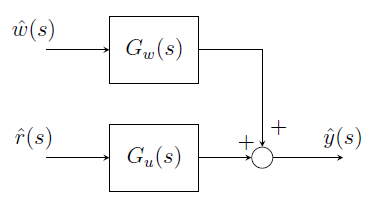

a saída deste sistema é descrita simplesmente por:

$$
\hat{y}(s)=G_u(s)\hat{r}(s)+G_w(s)\hat{w}(s)
$$

Onde a sensibilidade do sistema não-compensado em relação a perturbações pode ser analisada pelo diagrama de Bode da função de transferência de $G_w(s)$ no gráfico abaixo.

In [ ]:
# @title Diagrama de Bode de Gw
plt.close('all')

# Vetor de frequências (rad/s)
omega = np.logspace(-1, 3, 100000)

# -----------------------------
# Gráfico 1: Gw
# -----------------------------
plt.figure(2)
ct.bode_plot(Gw, omega=omega, dB=True, deg=True)
plt.suptitle('Diagrama de Bode de Gw')
plt.xlim([1e-1, 1e3])
plt.tight_layout()
plt.savefig('questao2diagramabode.png', dpi=450)

# -----------------------------
# Cálculo do valor máximo de magnitude de Gw
# -----------------------------
mag, phase, omega_resp = ct.frequency_response(Gw, omega)

# A magnitude é complexa → pegar valor absoluto
mag = np.abs(mag)
mag_db = 20 * np.log10(mag)

# Índice do valor máximo
idx_max = np.argmax(mag_db)

print("Valor máximo (dB):\n {:.4f} dB\n".format(mag_db[idx_max]))
print("Frequência (rad/s) em que ocorre o valor máximo:\n {:.4f} rad/s\n".format(omega_resp[idx_max]))

Discuta aqui a sensibilidade do sistema de suspensão não-compensado em relação a perturbações, por intepretação direta do diagram de Bode.

## Atividade 3)

A partir do diagrama de Bode da função de transferência $G_w(s)$, estimar a faixa de passagem $[w_a, w_b]$.

A faixa de passagem $[w_a, w_b]$ da suspensão não-compensada pode ser encontrada a partir dos pontos em que o diagrama de Bode de magnitude tem valor de $-3$ dB.

Portanto, conforme os cálculos a seguir, em $G_w(s)$:

$$
[w_a, w_b] = [????, ????] \ \text{rad/s}
$$

In [ ]:
# @title Faixa de passagem

# obtem os dados do diagrama de bode
mag, phase, omega = ct.bode_plot(Gw, dB=True, deg=True, omega_limits=[1e-2, 1e3], plot=False, omega_num=100000)

# obtem os pontos que passam por -3 dB
magdb = 20*np.log10(mag)
line3db = omega*0 - 3.0
index = np.argwhere(np.diff(np.sign(magdb - line3db))).flatten()

# plota o grafico de magnitude de Gw
plt.figure(1)
plt.plot(omega, magdb, zorder=2)
# plota a linha de -3 dB
plt.plot(omega, line3db, color='red', ls='--', zorder=2)
plt.annotate('-3 dB', (5e-2, -6), ha='center', va = 'top', fontweight='bold', color='red')
plt.suptitle('Pontos em que a função de transferência Gw passa por -3 dB')

# plota os pontos que interceptam a linha de -3 dB
plt.scatter(omega[index[0]], magdb[index[0]], color = 'red', edgecolors = 'black', zorder=3)
plt.scatter(omega[index[1]], magdb[index[1]], color = 'red', edgecolors = 'black', zorder=3)

# plota os valores correspondentes aos pontos
plt.annotate(r'$w_a=$'+'{0:.2f}'.format(omega[index[0]]), (omega[index[0]], magdb[index[0]]), xytext=(0, -70),textcoords='offset points', ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=1), arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
plt.annotate(r'$w_b=$'+'{0:.2f}'.format(omega[index[1]]), (omega[index[1]], magdb[index[1]]), xytext=(0, +30),textcoords='offset points', ha='center', va='bottom', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=1), arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

# configuracoes do grafico
plt.semilogx()
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.autoscale(axis='x', tight=True)
plt.grid()
plt.savefig('questao3bandapassagem.png', dpi=450)

## Atividade 4)

A faixa de passagem da parte passiva da suspensão do carro é um problema para o projeto, pois caso componentes de frequência do sinal de irregularidades $w(t)$ no padrão da rua sejam significativos nesta faixa de passagem, o efeito desta perturbação será sentido pelos passageiros do carro. Logo, é requisito de projeto fazer com que a compensação ativa garanta a atenuação da faixa de passagem da parte passiva da suspensão. Explique por que este objetivo pode ser atendido caso se defina a frequência de cruzamento $ w_c $ de $C(s)G_u(s)$ ao menos uma década acima da frequência $w_b$ da suspensão. Em seguida, proponha um valor para $ w_c $.

## Atividade 5)

Projete um ganho estático $k$ para que a frequência de cruzamento de $kG_u(s)$ fique aproximadamente uma década acima de $ω_b$.

O diagrama de Bode da função de transferência $G_u(s)$ é apresentado a seguir, mostrando que, na frequência desejada ($w_c = ????$ rad/s), a magnitude é de $????$ dB.

In [ ]:
# @title Diagrama de Bode de Gu
# Vetor de frequências
omega = np.logspace(-1, 4, 100000)

# -----------------------------
# Calcula resposta em frequência (dados)
# -----------------------------
mag, phase, omega_resp = ct.frequency_response(Gu, omega)

mag = np.abs(mag)
mag_db = 20 * np.log10(mag)

w_c = ???? # Inserir aqui a frequência de cruzamento desejada

# -----------------------------
# Encontra índice mais próximo de w_c rad/s
# -----------------------------
idx = np.argmin(np.abs(omega_resp - w_c))

# -----------------------------
# Gráfico 4: Bode de Gu
# -----------------------------
fig4 = plt.figure(4)
ct.bode_plot(Gu, omega=omega, dB=True, deg=True)
plt.suptitle('Diagrama de Bode de Gu')
plt.xlim([1e-1, 1e4])

# Marca o ponto
plt.gcf().axes[0].scatter(omega_resp[idx], mag_db[idx],
                          color='yellow', edgecolors='black', zorder=3)

plt.gcf().axes[0].annotate(f'{mag_db[idx]:.3f} dB',
                          (omega_resp[idx], mag_db[idx]),
                          xytext=(0, 30),
                          textcoords='offset points',
                          ha='center',
                          bbox=dict(boxstyle='round', fc='yellow'),
                          arrowprops=dict(arrowstyle='->'))

plt.savefig('questao5diagramabodeGu.png', dpi=450)

Assim, o valor de $k$ deve ser tal que, nessa frequência, a magnitude seja agora $0$ dB. Obtenha $k$, executando a célula a seguir.

$$
\boxed{k = ????}
$$

Verifique se, no diagrama de bode de $kG_u(s)$, apresentado ao executar o código logo abaixo, o valor de $k$ faz com que a frequência de cruzamento seja de $w_c$ rad/s, como desejado.

A partir desses passos do projeto, qual é a margem de fase $MF$ e qual é o ganho DC?

$$
\text{MF}=????°
$$

$$
\text{ganho DC}=????
$$

In [ ]:
# @title Diagrama de Bode de kGu
# -----------------------------
# Calcula ganho k
# -----------------------------
k = 10**(-mag_db[idx] / 20)

print('k = {:.4f}\n'.format(k))


# -----------------------------
# Gráfico 5: Bode de k*Gu
# -----------------------------
fig5 = plt.figure(5)
ct.bode_plot(k*Gu, omega=omega, dB=True, deg=True, margins=True)
plt.suptitle('Diagrama de Bode de kGu, com cálculo da margem de fase')
plt.xlim([1e-1, 1e4])
plt.savefig('questao5diagramabodekGu.png', dpi=450)

# -----------------------------
# Ganho DC
# -----------------------------
mag2, _, _ = ct.frequency_response(k*Gu, omega)
mag2 = np.abs(mag2)
mag2_db = 20 * np.log10(mag2)

print('O ganho DC é:\n{:.4f} dB\n'.format(mag2_db[0]))

## Atividade 6)

Projete um compensador do tipo avanço $C_a(s)$ para que o sistema compensado por $C(s)=kC_a(s)$ tenha $MF\geq30°$.

### Compensador do tipo avanço:

$$
C(s) = \underbrace{k_c \alpha}_{k} \, \frac{T s + 1}{\underbrace{\alpha T s + 1}_{C_a(s)}}
$$

com $0<α<1$ e $k$ projetado na Atividade 5.

### Determine a fase a ser adicionada

### Determine o parâmetro $α$

### Para se obter o parâmetro $T$, é necessário redefinir $w_m$ com base no ganho do compensador.

In [ ]:
# @title Diagrama de Bode de CGu

mf_def = ???? # @param

# calcula os parametros do controlador
phi_m = mf_def - ????
print(f'phi_m = {phi_m}')
alpha = (1 - np.sin(np.deg2rad(phi_m))) / (1 + np.sin(np.deg2rad(phi_m)))
print(f'alpha = {alpha}')


In [ ]:
k = 10**(-mag_db[idx] / 20)

ganho_compensador = ????

# -----------------------------
# Gráfico 6: Bode de k*Gu
# -----------------------------
fig6 = plt.figure(6)
ct.bode_plot(k*Gu, omega=omega, dB=True, deg=True)
plt.suptitle('Diagrama de Bode de kGu')
plt.xlim([1e-1, 1e4])

# obtém os dados do diagrama de Bode
mag, phase, _ = ct.frequency_response(k*Gu, omega)

# obtém os pontos que passam por menos o ganho do compensador, em dB
magdb = 20 * np.log10(mag)
line_compensador = omega*0 - ganho_compensador
index = np.argwhere(np.diff(np.sign(magdb - line_compensador))).flatten()

# Seleciona o gráfico de magnitude
plt.sca(plt.gcf().axes[0])

# plota a linha de menor ganho do compensador, em dB
plt.plot(omega, line_compensador, color='red', ls='--', zorder=2)
plt.annotate('-K_compensador dB', (5e-2, -6), ha='center', va = 'top', fontweight='bold', color='red')
plt.suptitle('Pontos em que a função de transferência k*Gu passa por menos o ganho do compensador, em dB')

# plota o ponto que interceptam a linha de menos o ganho do compensador, em dB
plt.scatter(omega[index[0]], magdb[index[0]], color = 'red', edgecolors = 'black', zorder=3)

# plota os valores correspondentes ao ponto
plt.annotate(r'$w=$'+'{0:.2f}'.format(omega[index[0]]), (omega[index[0]], magdb[index[0]]), xytext=(0, 70),textcoords='offset points', ha='center', va='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=1), arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))

# configuracoes do grafico
plt.semilogx()
plt.xlabel('Frequência (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.autoscale(axis='x', tight=True)
plt.grid()
plt.savefig('questao6adiagramabodekGu.png', dpi=450)

In [ ]:
wm = ???? # @param

T = 1/(wm*np.sqrt(alpha))
print(f'T = {T}')

# funcao de transferencia do controlador
k = 10**(-mag_db[idx] / 20)
C = k*(T*s + 1) / (T*alpha*s + 1)

# plota o grafico de k*Gu(s)
plt.figure(1)
ct.bode_plot(C*Gu, dB=True, deg=True,  omega_limits=[1e-1, 1e4], scalex=True, margins=True, omega_num=100000)
plt.suptitle('Diagrama de Bode de CGu, com cálculo da margem de fase')
plt.xlim([1e-1, 1e4])
plt.savefig('questao6diagramabodeCGu.png', dpi=450)

O diagrama de Bode de $C(s)G_u(s)$ é apresentado no gráfico acima. A margem de fase obtida, considerando-se os parâmetros usados acima, atende ao requisito de projeto de ser maior ou igual a 30°?

## Atividade 7)

Plotam-se, a seguir, os diagramas de Bode de $F(s)$ e de $S(s)$.

In [ ]:
C = k*(T*s + 1) / (T*alpha*s + 1)

F = C*Gu / (1 + C*Gu)
S = 1 / (1 + C*Gu)

# -----------------------------
# Bode de F e S
# -----------------------------
plt.figure(1)
# Plot F and S. The order in the list [F, S] determines the order of lines in the plot.
ct.bode_plot([F, S], omega_limits=[1e-1, 1e5])

# Get the current figure and its axes
fig = plt.gcf()
axes = fig.axes # axes[0] is magnitude plot, axes[1] is phase plot

# Set labels for the lines in the magnitude plot and display legend
if axes and len(axes) > 0 and len(axes[0].lines) >= 2:
    axes[0].lines[0].set_label('F') # Label for F
    axes[0].lines[1].set_label('S') # Label for S
    axes[0].legend(loc='best')

# Set labels for the lines in the phase plot and display legend
if axes and len(axes) > 1 and len(axes[1].lines) >= 2:
    axes[1].lines[0].set_label('F') # Label for F
    axes[1].lines[1].set_label('S') # Label for S
    axes[1].legend(loc='best')

plt.suptitle('Diagramas de Bode de F e S')
plt.xlim([1e-1, 1e5])
plt.savefig('questao7diagramabodeF.png', dpi=450)

O diagrama de Bode de $S(s)$ tem comportamento complementar ao de $F(s)$? Um deles é passa-alta e o outro é passa-baixa?

A seguir, é apresentado o diagrama de Bode de $S(s)G_w(s)$. O seu projeto de controle foi bem-sucedido? Justifique.

In [ ]:
# @title Diagrama de Bode de SGw
# -----------------------------
# Bode de S*Gw
# -----------------------------
plt.figure(3)
ct.bode_plot(S*Gw, dB=True, deg=True, omega_limits=[1e-1, 1e5], omega_num=100000)
plt.suptitle('Diagrama de Bode de SGw')
plt.xlim([1e-1, 1e5])
plt.savefig('questao7diagramabodeSGw.png', dpi=450)

# -----------------------------
# Cálculo do valor máximo de magnitude de S*Gw
# -----------------------------
mag, phase, omega_resp = ct.frequency_response(S*Gw, omega)

# A magnitude é complexa → pegar valor absoluto
mag = np.abs(mag)
mag_db = 20 * np.log10(mag)

# Índice do valor máximo
idx_max = np.argmax(mag_db)

print("Valor máximo (dB):\n {:.4f} dB\n".format(mag_db[idx_max]))
print("Frequência (rad/s) em que ocorre o valor máximo:\n {:.4f} rad/s\n".format(omega_resp[idx_max]))

## Atividade 8)

Diagrama de blocos do sistema compensado:

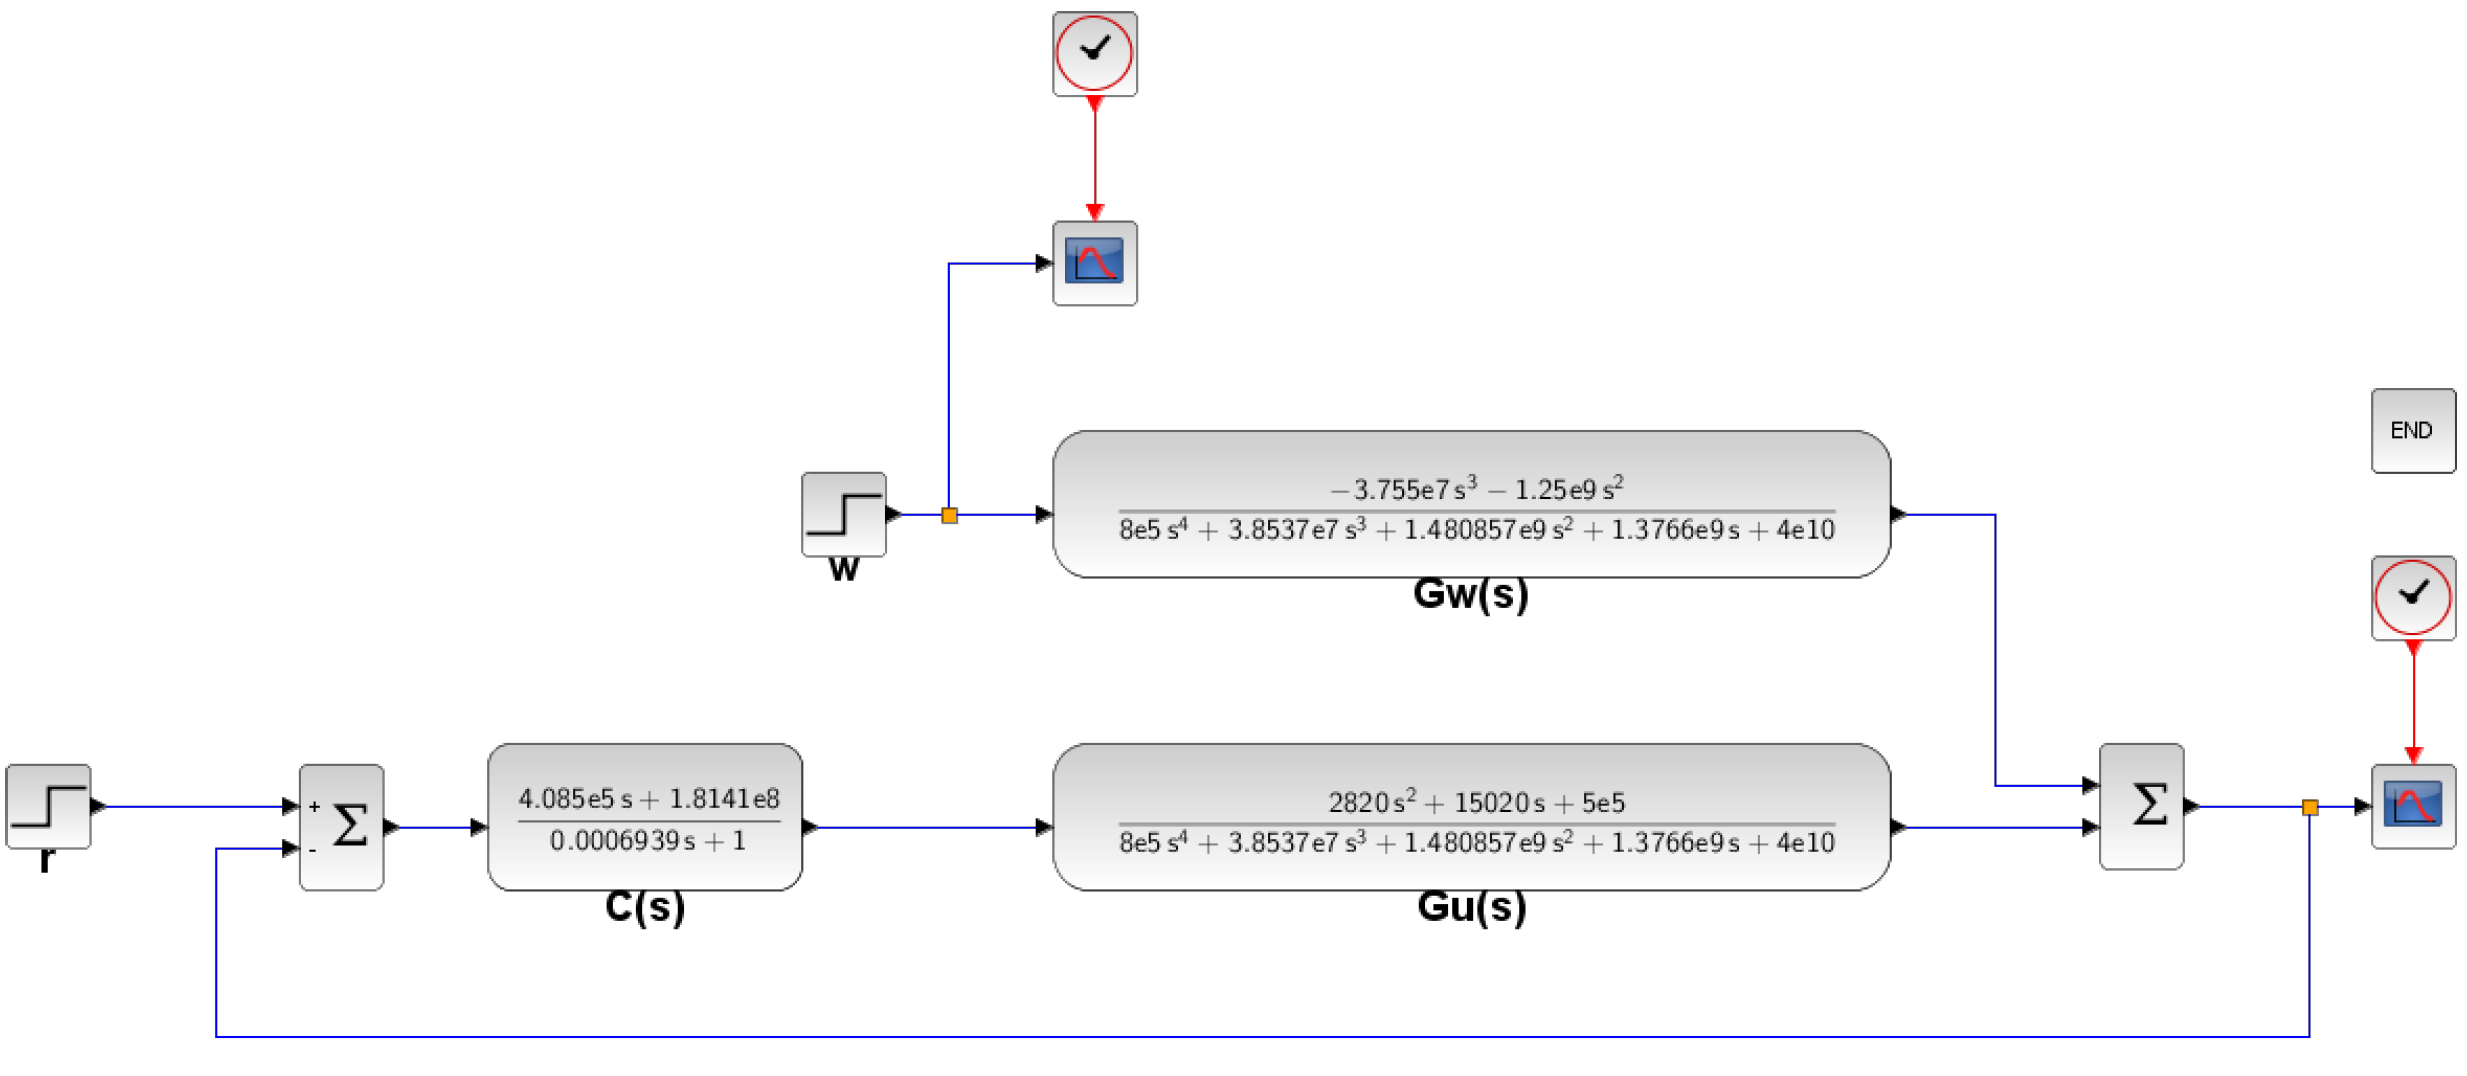

Diagrama de blocos do sistema não-compensado:

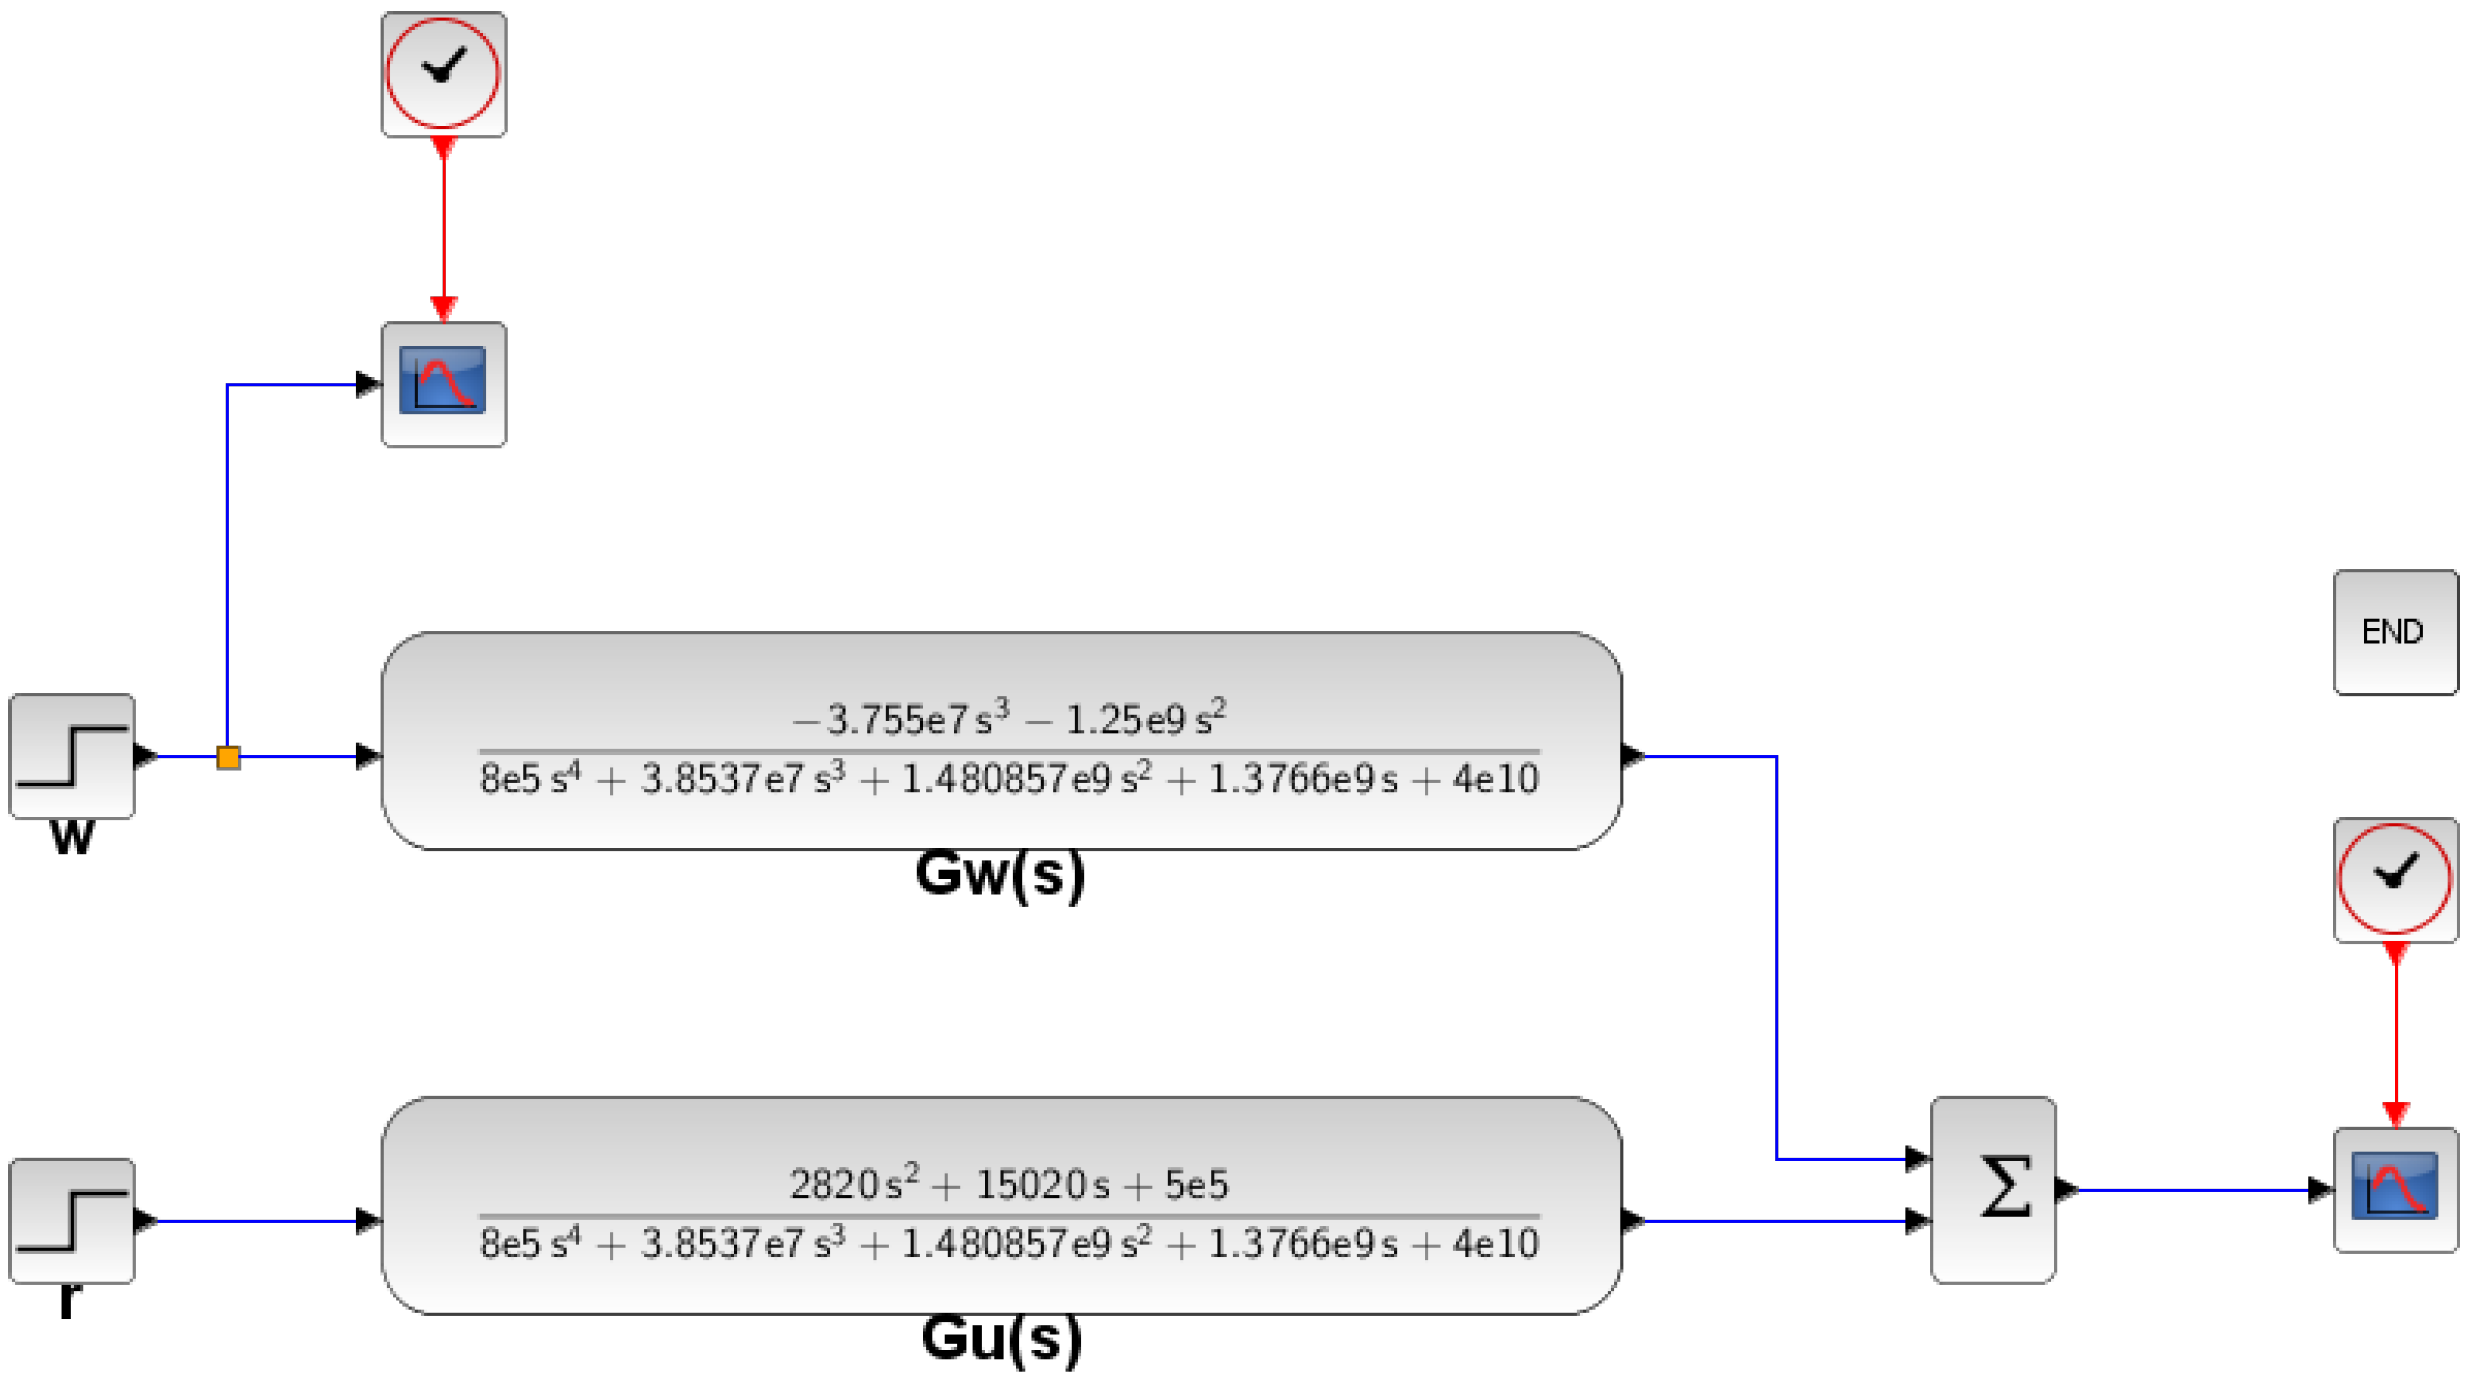

Valores encontrados nas atividades anteriores:

In [ ]:
# Variável s
s = ct.TransferFunction.s

# G_w(s)
Gw = (-3.755e7*s**3 - 1.25e9*s**2) / (
    8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10
)

# G_u(s)
Gu = (2820*s**2 + 15020*s + 5e5) / (
    8e5*s**4 + 3.8537e7*s**3 + 1.480857e9*s**2 + 1.3766e9*s + 4e10
)

# C(s)
C = k*(T*s + 1) / (T*alpha*s + 1)
print(f"Compensador obtido:\n{C}")

### Pertubação do tipo degrau

In [ ]:
# Perturbação: degrau de 0.1 em t = 0.5 s
df = pd.read_csv("degrau.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo degrau')

### Pertubação do tipo pulso

In [ ]:
# Perturbação: pulso de 0.1, período de 32s, largura de pulso de 50%, atraso de 0.5s
df = pd.read_csv("pulso.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo pulso')

### Pertubação do tipo senoidal: pior caso da suspensão não-compensada

Nesse caso, a perturbação é do tipo senoidal, com frequência de 5,254 rad/s selecionada deliberadamente em razão de ser a perturbação que produz o pior desempenho da suspensão não compensada. Como discutido anteriormente, a resposta da suspensão não compensada depende essencialmente de Gw(s), cujo diagrama de Bode foi apresentado e discutido na Atividade 2, em que foi identificado um pico de 26,43 dB nessa frequência, indicando uma amplificação por um fator de 10^(26,43/20) ≈ 20,965. Além disso, a amplitude da entrada é de 0,1 m (valor de pico a pico de 0,2 m).

In [ ]:
# Perturbação: senoide de amplitude 0.1 e frequencia de 5.254 rad/s (pior caso da suspensao nao compensada)
df = pd.read_csv("senoide_pior_caso_nao_compensado.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo senoidal (5.254 rad/s)')

### Pertubação do tipo senoidal: pior caso da suspensão compensada

Novamente, a perturbação é do tipo senoidal, mas agora com frequência de 1205,7 rad/s selecionada deliberadamente em razão de ser a perturbação que produz o pior desempenho da suspensão compensada. Esse valor foi obtido do pico do diagrama de Bode de magnitude de $S(s)G_w(s)$ da Atividade 7. A amplitude da entrada é de 0,1 m (valor de pico a pico de 0,2 m).

In [ ]:
# Perturbação: senoide de amplitude 0.1 e frequencia de 1205.7 rad/s (pior caso da suspensao compensada)
df = pd.read_csv("senoide_pior_caso_compensado.csv")
plot_resposta_sistema(df, Gw, Gu, C, titulo='Sistema compensado vs. não compensado <br> perturbação do tipo senoidal (1205.7 rad/s)')